# 07 — Multi-task camera perception and federated learning

*The full dataset remains outside Git. These notebooks combine synthetic worked examples, aggregate evidence, and small attributed qualitative panels.*

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

In [2]:
central = json.loads((ROOT/'reports/multitask_central_test.json').read_text())
central_training = json.loads((ROOT/'reports/multitask_central_training.json').read_text())
federated = json.loads((ROOT/'reports/multitask_federated_test.json').read_text())
fedsgd = json.loads((ROOT/'reports/multitask_fedsgd_test.json').read_text())
fedsgd_sweep = {
    '0.001': json.loads((ROOT/'reports/multitask_fedsgd_lr1e3_validation.json').read_text()),
    '0.003': json.loads((ROOT/'reports/multitask_fedsgd_lr3e3_validation.json').read_text()),
    '0.010': json.loads((ROOT/'reports/multitask_fedsgd_lr1e2_validation.json').read_text()),
}
data_receipt = json.loads((ROOT/'reports/multitask_federated_data.json').read_text())
print('Public aggregate reports loaded; raw ZOD paths and recording IDs are not needed.')

Public aggregate reports loaded; raw ZOD paths and recording IDs are not needed.


## Why I added this experiment

I wanted to understand two ideas that often appear together in fleet learning.
One camera encoder can support several scene-understanding objectives, and
vehicles can train locally while sharing model updates instead of raw
recordings. Neither idea is automatically beneficial: tasks can fight through
shared gradients, while non-IID clients can pull a global model in incompatible
directions.

This notebook reconstructs the experiment from label provenance through model-
delta FedAvg and gradient-only FedSGD. It is a sequential, single-machine
federated optimization simulation—not secure aggregation or differential privacy.

## One input and three task families

One blurred front RGB keyframe produces:

1. **segmentation:** 19 Cityscapes scene classes plus independent native ZOD
   ego-road and lane masks;
2. **monocular depth:** metric depth supervised only where calibrated LiDAR
   projects into the camera;
3. **2-D detection:** Vehicle, Pedestrian, and Cyclist center heatmaps, offsets,
   and box sizes.

The 19-class maps are frozen SegFormer teacher pseudo-labels. Their metric is
teacher agreement, not ZOD semantic ground-truth accuracy. Road/lane, depth,
and boxes use native ZOD geometry.

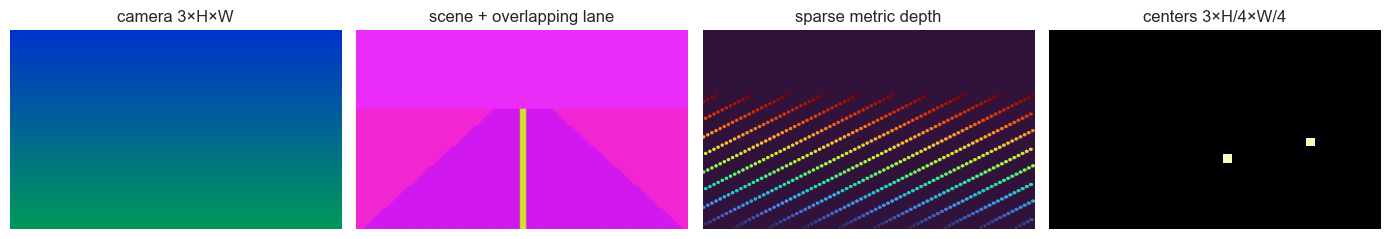

In [3]:
# A data-safe synthetic sample makes the tensor contracts visible.
H,W=96,160; OH,OW=H//4,W//4
yy,xx=np.mgrid[:H,:W]
rgb=np.zeros((H,W,3),float); rgb[...,2]=.35+.45*(1-yy/H); rgb[...,1]=.2+.4*(yy/H)
scene=np.where(yy<38,10,np.where(np.abs(xx-W/2)<(yy-25)*1.1,0,8))
road=scene==0; lane=road & (np.abs(xx-W/2)<1.5)
depth=np.zeros((H,W)); valid=((xx+2*yy)%17==0)&(yy>30); depth[valid]=8+42*(1-yy[valid]/H)
heat=np.zeros((3,OH,OW)); heat[0,15,21]=1; heat[1,13,31]=1
fig,ax=plt.subplots(1,4,figsize=(14,3.2))
ax[0].imshow(rgb); ax[0].set_title('camera 3×H×W')
ax[1].imshow(scene,cmap='tab20'); ax[1].imshow(lane,cmap='spring',alpha=.8); ax[1].set_title('scene + overlapping lane')
ax[2].imshow(depth,cmap='turbo'); ax[2].scatter(xx[valid],yy[valid],s=2,c=depth[valid],cmap='turbo'); ax[2].set_title('sparse metric depth')
ax[3].imshow(heat.max(0),cmap='magma'); ax[3].set_title('centers 3×H/4×W/4')
for axis in ax: axis.axis('off')
plt.tight_layout(); plt.show()

## RGB preprocessing and the inference contract

The cached camera frame is resized bilinearly to $192\times320$, converted from
uint8 to $[0,1]$, and normalized with ImageNet statistics:

\[
x'_{cuv}=\frac{x_{cuv}-\mu_c}{\sigma_c},\quad
\mu=(0.485,0.456,0.406),\quad
\sigma=(0.229,0.224,0.225).
\]

All geometric targets are resized into the same image convention; discrete
masks use nearest-neighbor interpolation. I did not add random augmentation in
this bounded comparison, so architecture and federated-protocol differences are
not mixed with a changing augmentation policy. At inference the network receives
**only this RGB tensor**. SegFormer pseudo-labels, polygons, 2-D annotations, and
LiDAR are supervision used while building the training cache, not model inputs.

In [4]:
pixel=np.array([128,170,210],dtype=float)/255
mean=np.array([.485,.456,.406]); std=np.array([.229,.224,.225])
pd.DataFrame({'channel':['R','G','B'],'unit_interval':pixel,'normalized':(pixel-mean)/std}).round(3)

,channel,unit_interval,normalized
0,R,0.502,0.074
1,G,0.667,0.940
2,B,0.824,1.856


## Calibration, projection, and sparse depth

A LiDAR point is motion-compensated, transformed into the current ego frame,
and then into the front camera:

\[
p^c=(T^e_c)^{-1}p^e.
\]

ZOD's calibrated Kannala–Brandt model gives image coordinates. I supervise
optical-axis depth $z^c$, retain positive in-image points, and use a z-buffer so
the nearest return wins a resized-pixel collision. A Boolean validity mask
ensures pixels without LiDAR contribute no depth loss.

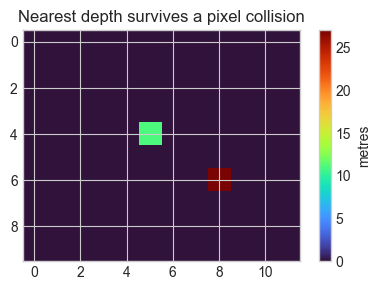

In [5]:
pixels=np.array([[5.1,4.9],[5.4,4.7],[8.2,6.1]]); depths=np.array([18.,11.,27.])
flat=np.full(10*12,np.inf); indices=pixels[:,1].astype(int)*12+pixels[:,0].astype(int)
np.minimum.at(flat,indices,depths); depth_map=flat.reshape(10,12); depth_map[~np.isfinite(depth_map)]=0
plt.figure(figsize=(5,3)); plt.imshow(depth_map,cmap='turbo'); plt.colorbar(label='metres')
plt.title('Nearest depth survives a pixel collision'); plt.show()

## Dense monocular output, sparse metric evaluation

The depth decoder produces one dense log-depth value per camera pixel. I recover
metric depth with $\hat d=\exp(\hat \ell)$ and clamp it to the supervised
$[0.5,120]$ metre range. Loss and metrics use only the set $V$ of pixels with a
valid projected LiDAR return. Therefore this is **monocular metric depth learned
from sparse LiDAR supervision**, not dense LiDAR completion and not proof of
dense accuracy between returns.

For $N=|V|$ valid pixels, I report

\[
\operatorname{AbsRel}=\frac1N\sum_{q\in V}
\frac{|\hat d_q-d_q|}{d_q},\qquad
\operatorname{RMSE}=\sqrt{\frac1N\sum_{q\in V}(\hat d_q-d_q)^2},
\]

\[
\delta_1=\frac1N\sum_{q\in V}
\mathbf 1\!\left[\max\!\left(\frac{\hat d_q}{d_q},
\frac{d_q}{\hat d_q}\right)<1.25\right].
\]

AbsRel and RMSE are lower-is-better; $\delta_1$ is higher-is-better and measures
the fraction predicted within a multiplicative factor of 1.25.

In [6]:
truth=np.array([8.,12.,20.,40.]); prediction=np.array([8.5,10.,24.,55.])
absrel=np.mean(np.abs(prediction-truth)/truth)
rmse=np.sqrt(np.mean((prediction-truth)**2))
ratio=np.maximum(prediction/truth,truth/prediction); delta1=np.mean(ratio<1.25)
pd.Series({'AbsRel':absrel,'RMSE_m':rmse,'delta1':delta1}).round(3)

AbsRel    0.201
RMSE_m    7.830
delta1    0.750
dtype: float64

## Center-based 2-D detection

Each native ZOD box is scaled to the stride-four output grid. A Gaussian marks
its class center; the positive cell predicts fractional offset
$o=(c_x-j,c_y-i)$ and size $(w,h)$:

\[
L_{det}=L_{focal}(\hat H,H)+\lVert\hat o-o\rVert_1
+0.1\lVert\hat s-s\rVert_1.
\]

This is a compact CenterNet-style learning head, not a replacement for the
stronger LiDAR BEV detector elsewhere in the project.

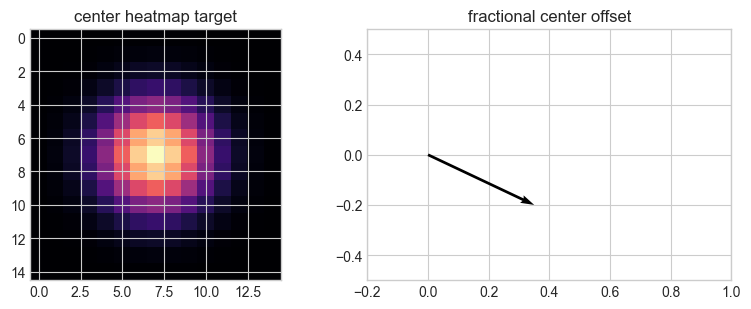

In [7]:
x=np.arange(-7,8); X,Y=np.meshgrid(x,x); gaussian=np.exp(-(X**2+Y**2)/(2*2.2**2))
fig,ax=plt.subplots(1,2,figsize=(8,3.2)); ax[0].imshow(gaussian,cmap='magma'); ax[0].set_title('center heatmap target')
ax[1].quiver([0],[0],[.35],[-.2],angles='xy',scale_units='xy',scale=1); ax[1].set_xlim(-.2,1); ax[1].set_ylim(-.5,.5); ax[1].set_title('fractional center offset'); ax[1].grid(True)
plt.tight_layout(); plt.show()

## Losses with different units

Scene semantics use multiclass cross entropy. Native road/lane use weighted
binary cross entropy plus soft Dice. Depth uses Smooth-L1 in log metres only at
valid LiDAR pixels:

\[
L_{depth}=|V|^{-1}\sum_{q\in V}
\operatorname{SmoothL1}(\hat d_q,\log d_q).
\]

Equal weighting sums the task losses. The uncertainty control learns task log
variances $s_t$ and minimizes

\[
L=\sum_t e^{-s_t}L_t+\tfrac12s_t.
\]

This follows Kendall, Gal, and Cipolla; learned weighting remains a hypothesis
to validate rather than an automatic improvement.

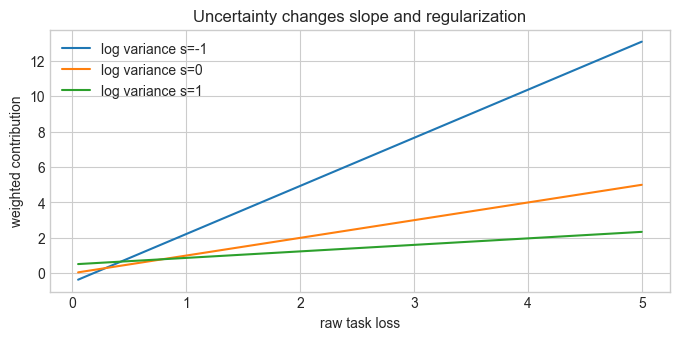

In [8]:
loss=np.linspace(.05,5,200); fig,ax=plt.subplots(figsize=(8,3.4))
for s in (-1,0,1): ax.plot(loss,np.exp(-s)*loss+.5*s,label=f'log variance s={s}')
ax.set(xlabel='raw task loss',ylabel='weighted contribution',title='Uncertainty changes slope and regularization'); ax.legend(); plt.show()

## Separate, hard-shared, and split-decoder models

- Three separate 14.48M networks avoid interference but total 43.44M parameters
  and repeat the encoder three times.
- Hard sharing uses one encoder and one spatial decoder. It is efficient, but
  every task competes for the same representation and upsampling path.
- The split model shares ResNet-18 while giving semantics, depth, and detection
  independent decoders. It has 19.80M parameters—about 54% fewer than the three
  separate controls together.

In [9]:
runs={row['variant']:row for row in central['runs']}; rows=[]
for name,row in runs.items():
    test=row['test']; aff=test['affordance']; dep=test['depth']
    rows.append([name,row['parameter_count']/1e6,row['latency_batch_1']['median_ms'],test['scene_teacher_miou'],aff['lane_tolerant_f1'],dep['delta1'],test['detection_map50']])
central_table=pd.DataFrame(rows,columns=['model','parameters_M','latency_ms','teacher_mIoU','lane_F1','depth_delta1','detection_mAP50'])
display(central_table.round(3))

,model,parameters_M,latency_ms,teacher_mIoU,lane_F1,depth_delta1,detection_mAP50
0,single_segmentation,14.480,2.990,0.227,0.630,0.019,0.000
1,single_depth,14.480,3.042,0.017,0.059,0.354,0.000
2,single_detection,14.480,3.066,0.008,0.062,0.004,0.034
3,shared_equal,14.480,3.062,0.187,0.000,0.387,0.029
4,shared_uncertainty,14.480,3.044,0.183,0.000,0.362,0.033
5,split_equal,19.803,4.707,0.225,0.705,0.358,0.025
6,split_uncertainty,19.803,4.563,0.228,0.713,0.409,0.046


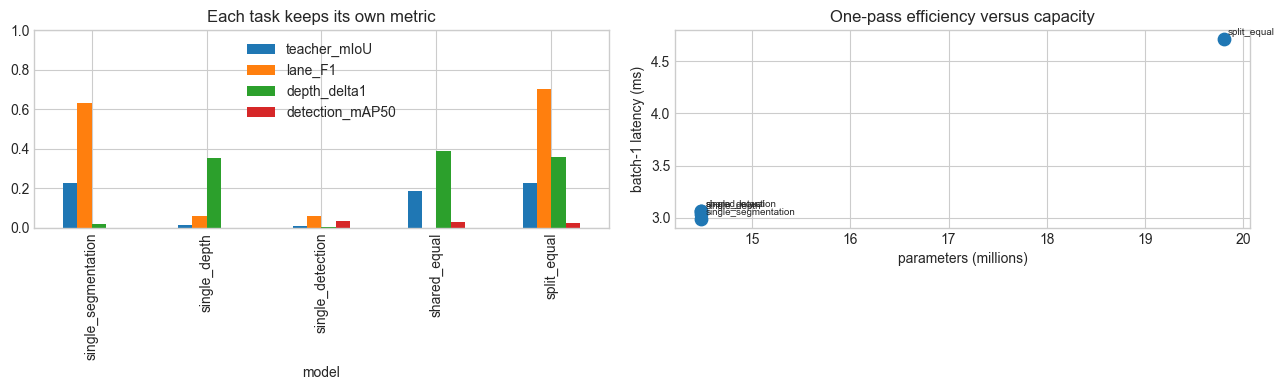

In [10]:
selected=central_table[central_table.model.isin(['single_segmentation','single_depth','single_detection','shared_equal','split_equal'])]
fig,ax=plt.subplots(1,2,figsize=(13,4))
selected.set_index('model')[['teacher_mIoU','lane_F1','depth_delta1','detection_mAP50']].plot.bar(ax=ax[0]); ax[0].set_ylim(0,1); ax[0].set_title('Each task keeps its own metric')
ax[1].scatter(selected.parameters_M,selected.latency_ms,s=80)
for _,row in selected.iterrows(): ax[1].annotate(row.model,(row.parameters_M,row.latency_ms),fontsize=7,xytext=(3,3),textcoords='offset points')
ax[1].set(xlabel='parameters (millions)',ylabel='batch-1 latency (ms)',title='One-pass efficiency versus capacity')
plt.tight_layout(); plt.show()

## Negative transfer is measurable

Shared encoder task gradients have cosine

\[
\cos(g_i,g_j)=\frac{g_i^Tg_j}{\lVert g_i\rVert\lVert g_j\rVert}.
\]

A negative value means one local step helps one objective while opposing the
other. PCGrad projects conflicting components away; I keep it as a literature
connection rather than claiming it was benchmarked. My implemented response is
structural: split the task decoders while retaining an encoder.

,model,task_pair,cosine
0,split_equal,depth_vs_detection,-0.001
1,split_equal,segmentation_vs_depth,0.003
2,split_equal,segmentation_vs_detection,0.031
3,split_uncertainty,depth_vs_detection,-0.012
4,split_uncertainty,segmentation_vs_depth,-0.012
5,split_uncertainty,segmentation_vs_detection,0.029


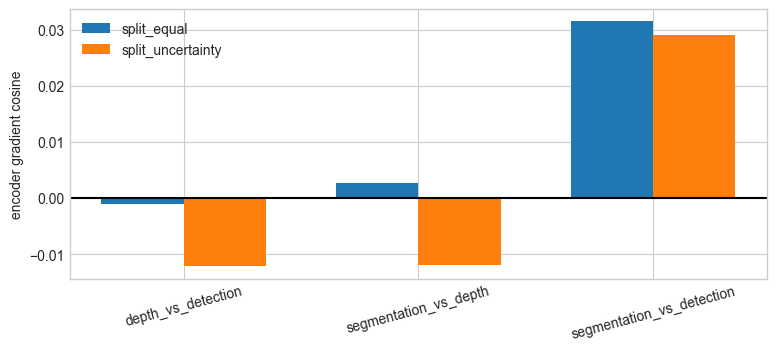

In [11]:
gradient_rows=[]
for run in central_training['runs']:
    for pair,value in run['gradient_cosines'].items(): gradient_rows.append([run['variant'],pair,value])
gradients=pd.DataFrame(gradient_rows,columns=['model','task_pair','cosine']); display(gradients.round(3))
fig,ax=plt.subplots(figsize=(9,3.5)); width=.35
for index,(name,group) in enumerate(gradients.groupby('model')): ax.bar(np.arange(len(group))+(index-.5)*width,group.cosine,width,label=name)
ax.axhline(0,color='black'); ax.set_xticks(range(3),gradients.task_pair.unique(),rotation=15); ax.set_ylabel('encoder gradient cosine'); ax.legend(); plt.show()

## Uneven non-IID clients

The previous training role is partitioned before federated optimization. Each
private collection car becomes one simulated client with 65/40/25/15 samples.
Only 22/11/6/2 client samples have LiDAR depth. Country and object frequencies
also differ. Validation and test remain outside every client.

,client,samples,depth_samples,vehicles,pedestrians,cyclists
0,client_0,65,22,973,88,32
1,client_1,40,11,575,72,25
2,client_2,25,6,477,26,4
3,client_3,15,2,183,19,3


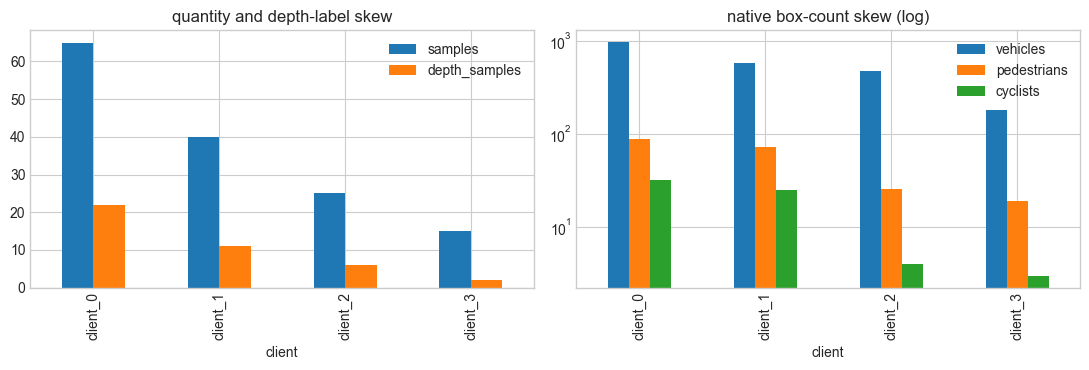

In [12]:
roles=data_receipt['roles']; clients=[f'client_{i}' for i in range(4)]
client_frame=pd.DataFrame([{
    'client':name,'samples':roles[f'federated/{name}']['samples'],
    'depth_samples':roles[f'federated/{name}']['depth_supervised_samples'],
    'vehicles':roles[f'federated/{name}']['object_instances']['Vehicle'],
    'pedestrians':roles[f'federated/{name}']['object_instances']['Pedestrian'],
    'cyclists':roles[f'federated/{name}']['object_instances']['Cyclist'],
} for name in clients])
display(client_frame)
fig,ax=plt.subplots(1,2,figsize=(11,3.8))
client_frame.set_index('client')[['samples','depth_samples']].plot.bar(ax=ax[0])
client_frame.set_index('client')[['vehicles','pedestrians','cyclists']].plot.bar(ax=ax[1],logy=True)
ax[0].set_title('quantity and depth-label skew'); ax[1].set_title('native box-count skew (log)'); plt.tight_layout(); plt.show()

## FedAvg and client influence

For client sample count $n_k$, sample-weighted FedAvg uses

\[
w^{r+1}=\sum_k\frac{n_k}{\sum_j n_j}w_k^{r+1}.
\]

Uniform averaging is the deliberate control. It gives each client 0.25, so the
15-sample client receives 2.42 times its sample-proportional influence and the
65-sample client only 0.56 times its proportional influence. Sample weighting
estimates the pooled empirical objective; it does not solve every fairness or
domain-coverage question.

,client,samples,FedAvg_weight,uniform_weight,uniform_over_FedAvg
0,client_0,65,0.448,0.25,0.558
1,client_1,40,0.276,0.25,0.906
2,client_2,25,0.172,0.25,1.450
3,client_3,15,0.103,0.25,2.417


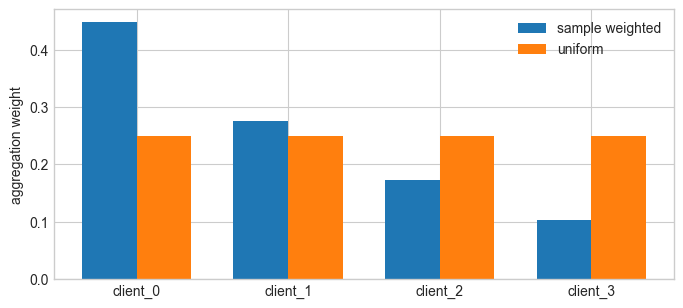

In [13]:
counts=client_frame.samples.to_numpy(); weighted=counts/counts.sum(); uniform=np.ones(4)/4
influence=pd.DataFrame({'client':clients,'samples':counts,'FedAvg_weight':weighted,'uniform_weight':uniform,'uniform_over_FedAvg':uniform/weighted})
display(influence.round(3))
fig,ax=plt.subplots(figsize=(8,3.5)); x=np.arange(4)
ax.bar(x-.18,weighted,.36,label='sample weighted'); ax.bar(x+.18,uniform,.36,label='uniform')
ax.set_xticks(x,clients); ax.set_ylabel('aggregation weight'); ax.legend(); plt.show()

## What actually crosses the client/server boundary

I compare three fundamentally different arrangements:

1. **Pooled retraining:** move all samples into one central loader. This is a
   useful upper control but is not federated learning.
2. **FedSGD:** broadcast the current weights, compute one mean gradient on each
   client, transmit gradients, and let the server take one global SGD step:

   \[
   g_k=\nabla F_k(w^r),\qquad
   w^{r+1}=w^r-\eta\sum_k p_k g_k.
   \]

3. **FedAvg/FedProx:** broadcast the current weights, perform local optimizer
   steps, and transmit only the resulting model delta
   \(\Delta_k=w_k^{r+1}-w^r\):

   \[
   w^{r+1}=w^r+\sum_k p_k\Delta_k.
   \]

If every client starts from the same \(w^r\), averaging complete client weights
and averaging their deltas are algebraically identical because \(\sum_kp_k=1\).
The implementation uses deltas explicitly so the simulated message matches the
concept. Neither gradients nor deltas reveal raw images directly, but both can
leak information and have the same dimensionality as the trainable model unless
they are quantized, sparsified, or otherwise compressed.

In [14]:
# Numerical proof: full-weight averaging and delta averaging agree.
server=np.array([2.0,-1.0,0.5]); clients_w=np.array([[2.4,-.8,.4],[1.7,-1.2,.8]])
p=np.array([.25,.75])
full=(p[:,None]*clients_w).sum(0)
via_delta=server+(p[:,None]*(clients_w-server)).sum(0)
pd.DataFrame({'full_weight_average':full,'server_plus_mean_delta':via_delta,'difference':full-via_delta})

,full_weight_average,server_plus_mean_delta,difference
0,1.875,1.875,0.000000e+00
1,-1.100,-1.100,2.220446e-16
2,0.700,0.700,0.000000e+00


## Local optimization, FedProx, and drift

Every FedAvg round broadcasts $w^r$, performs local AdamW steps, and aggregates
the returned deltas. FedSGD instead evaluates every client gradient at exactly
the same untouched $w^r$ and applies one sample-weighted server step.
FedProx modifies client $k$'s objective:

\[
F_k(w)+\frac{\mu}{2}\lVert w-w^r\rVert_2^2,
\qquad \mu=10^{-3}.
\]

The penalty resists movement away from the server under heterogeneity. Pooled
fine-tuning is an oracle because it combines all client samples and breaks the
federated raw-data boundary. Head-only FedAvg freezes the shared encoder to
reduce representation drift and transmitted parameters.

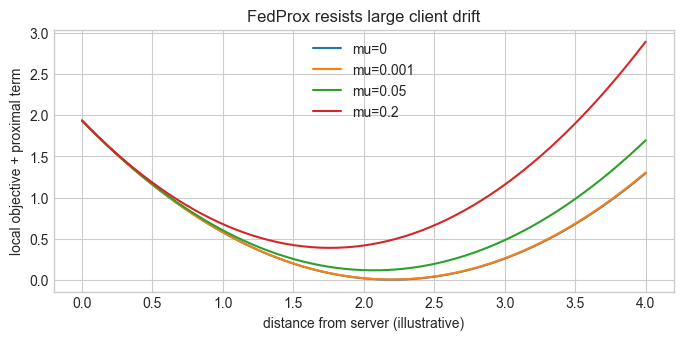

In [15]:
distance=np.linspace(0,4,200); fig,ax=plt.subplots(figsize=(8,3.4))
for mu in (0,1e-3,.05,.2): ax.plot(distance,.4*(distance-2.2)**2+.5*mu*distance**2,label=f'mu={mu:g}')
ax.set(xlabel='distance from server (illustrative)',ylabel='local objective + proximal term',title='FedProx resists large client drift'); ax.legend(); plt.show()

## Round zero is a model candidate

The centralized checkpoint is round zero. It remains eligible because an
update should not be deployed merely because communication occurred. At the
original learning rate every local-optimizer method fell below round zero. Reducing the rate
to 2e-5 reduced drift, but pooled, uniform, FedAvg, and FedProx still selected
round zero. Freezing the encoder did not repair validation performance. FedSGD
behaved differently: a validation-only learning-rate sweep selected
$\eta=0.003$, and its mean-gradient update exceeded round zero.

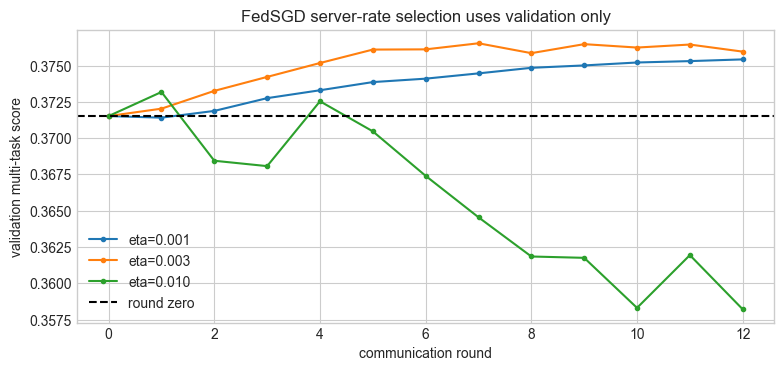

In [16]:
fig,ax=plt.subplots(figsize=(9,3.8))
for rate,report in fedsgd_sweep.items():
    method=report['methods'][0]; baseline=report['base_validation']['selection_score']
    ax.plot([0]+[r['round'] for r in method['history']],[baseline]+[r['validation']['selection_score'] for r in method['history']],marker='o',ms=3,label=f'eta={rate}')
ax.axhline(fedsgd['base_validation']['selection_score'],color='black',ls='--',label='round zero')
ax.set(xlabel='communication round',ylabel='validation multi-task score',title='FedSGD server-rate selection uses validation only'); ax.legend(); plt.show()

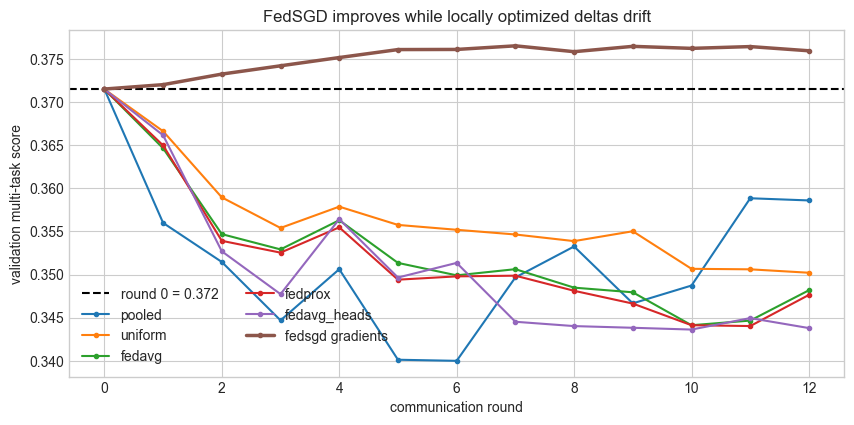

In [17]:
base=federated['base_validation']['selection_score']; fig,ax=plt.subplots(figsize=(10,4.5))
ax.axhline(base,color='black',ls='--',label=f'round 0 = {base:.3f}')
for method in federated['methods']:
    history=method['history']; ax.plot([0]+[r['round'] for r in history],[base]+[r['validation']['selection_score'] for r in history],marker='o',ms=3,label=method['method'])
gradient=fedsgd['methods'][0]; gradient_base=fedsgd['base_validation']['selection_score']
ax.plot([0]+[r['round'] for r in gradient['history']],[gradient_base]+[r['validation']['selection_score'] for r in gradient['history']],marker='o',ms=3,lw=2.5,label='fedsgd gradients')
ax.set(xlabel='communication round',ylabel='validation multi-task score',title='FedSGD improves while locally optimized deltas drift'); ax.legend(ncol=2); plt.show()

In [18]:
decision=pd.DataFrame(
    [['centralized split decoder',0,base,'promote']]
    + [[m['method'],m['best_round'],m['best_validation_score'],'no update'] for m in federated['methods']]
    + [['fedsgd',gradient['best_round'],gradient['best_validation_score'],'promote update']],
    columns=['candidate','selected_round','validation_score','decision'])
decision.round(4)

,candidate,selected_round,validation_score,decision
0,centralized split decoder,0,0.3715,promote
1,pooled,0,0.3715,no update
2,uniform,0,0.3715,no update
3,fedavg,0,0.3715,no update
4,fedprox,0,0.3715,no update
5,fedavg_heads,0,0.3715,no update
6,fedsgd,7,0.3765,promote update


## Communication and the privacy boundary

The 19.80M-parameter model is about 75.5 MiB in FP32. Four full-model clients
sending and receiving it for 12 rounds move roughly 7.1 GiB before protocol
overhead. Federated learning avoids raw-data centralization; it does not make
communication free.

The server sees model deltas or gradients and sample counts. One FP32 gradient
or full-model delta still contains one scalar per trainable parameter, so the
uncompressed byte count is essentially the same. There is no secure
aggregation, clipping, noise, privacy accountant, malicious-server analysis,
or membership-inference evaluation. I therefore call this a **federated
optimization simulation**, never a privacy guarantee.

In [19]:
model_bytes=19_803_069*4; rounds=12; client_count=4
communication=pd.DataFrame([
    ['one FP32 model',model_bytes/2**20,'MiB'],
    ['campaign uplink',model_bytes*rounds*client_count/2**30,'GiB'],
    ['campaign downlink',model_bytes*rounds*client_count/2**30,'GiB'],
],columns=['transfer','value','unit'])
display(communication.round(2))
pd.Series(data_receipt['federated_contract'])[['raw_data_transmitted','secure_aggregation','differential_privacy','simulation_note']]

,transfer,value,unit
0,one FP32 model,75.54,MiB
1,campaign uplink,3.54,GiB
2,campaign downlink,3.54,GiB


raw_data_transmitted                                                False
secure_aggregation                                                  False
differential_privacy                                                False
simulation_note         all client optimization runs sequentially on o...
dtype: object

## Reading the inference gallery

The validation-selected round-7 FedSGD model shows RGB input, teacher and student
scene maps, native road/lane targets and predictions, monocular depth with
sparse LiDAR supervision, and native versus predicted boxes. The frames come
from independent recordings: this GIF is an inference gallery, not a temporal
driving sequence.

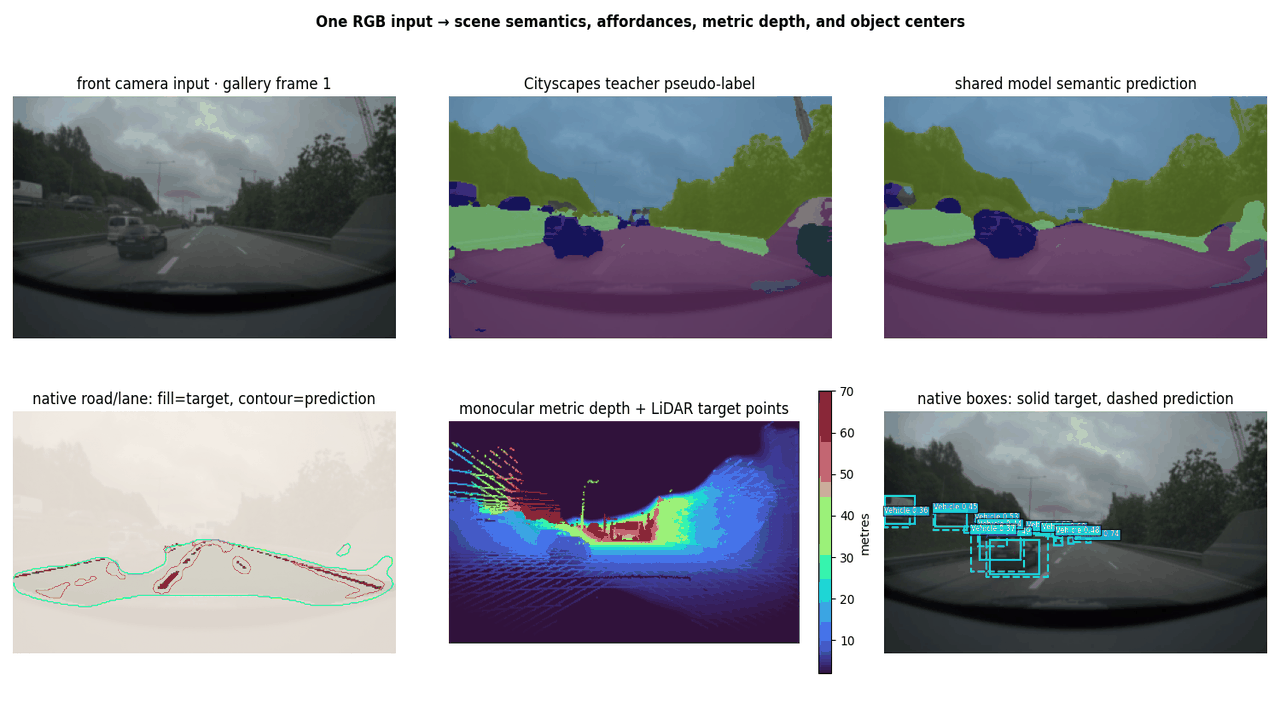

In [20]:
from IPython.display import Image as NotebookImage, display
display(NotebookImage(filename=str(ROOT/'reports/figures/multitask_camera_inference.gif')))

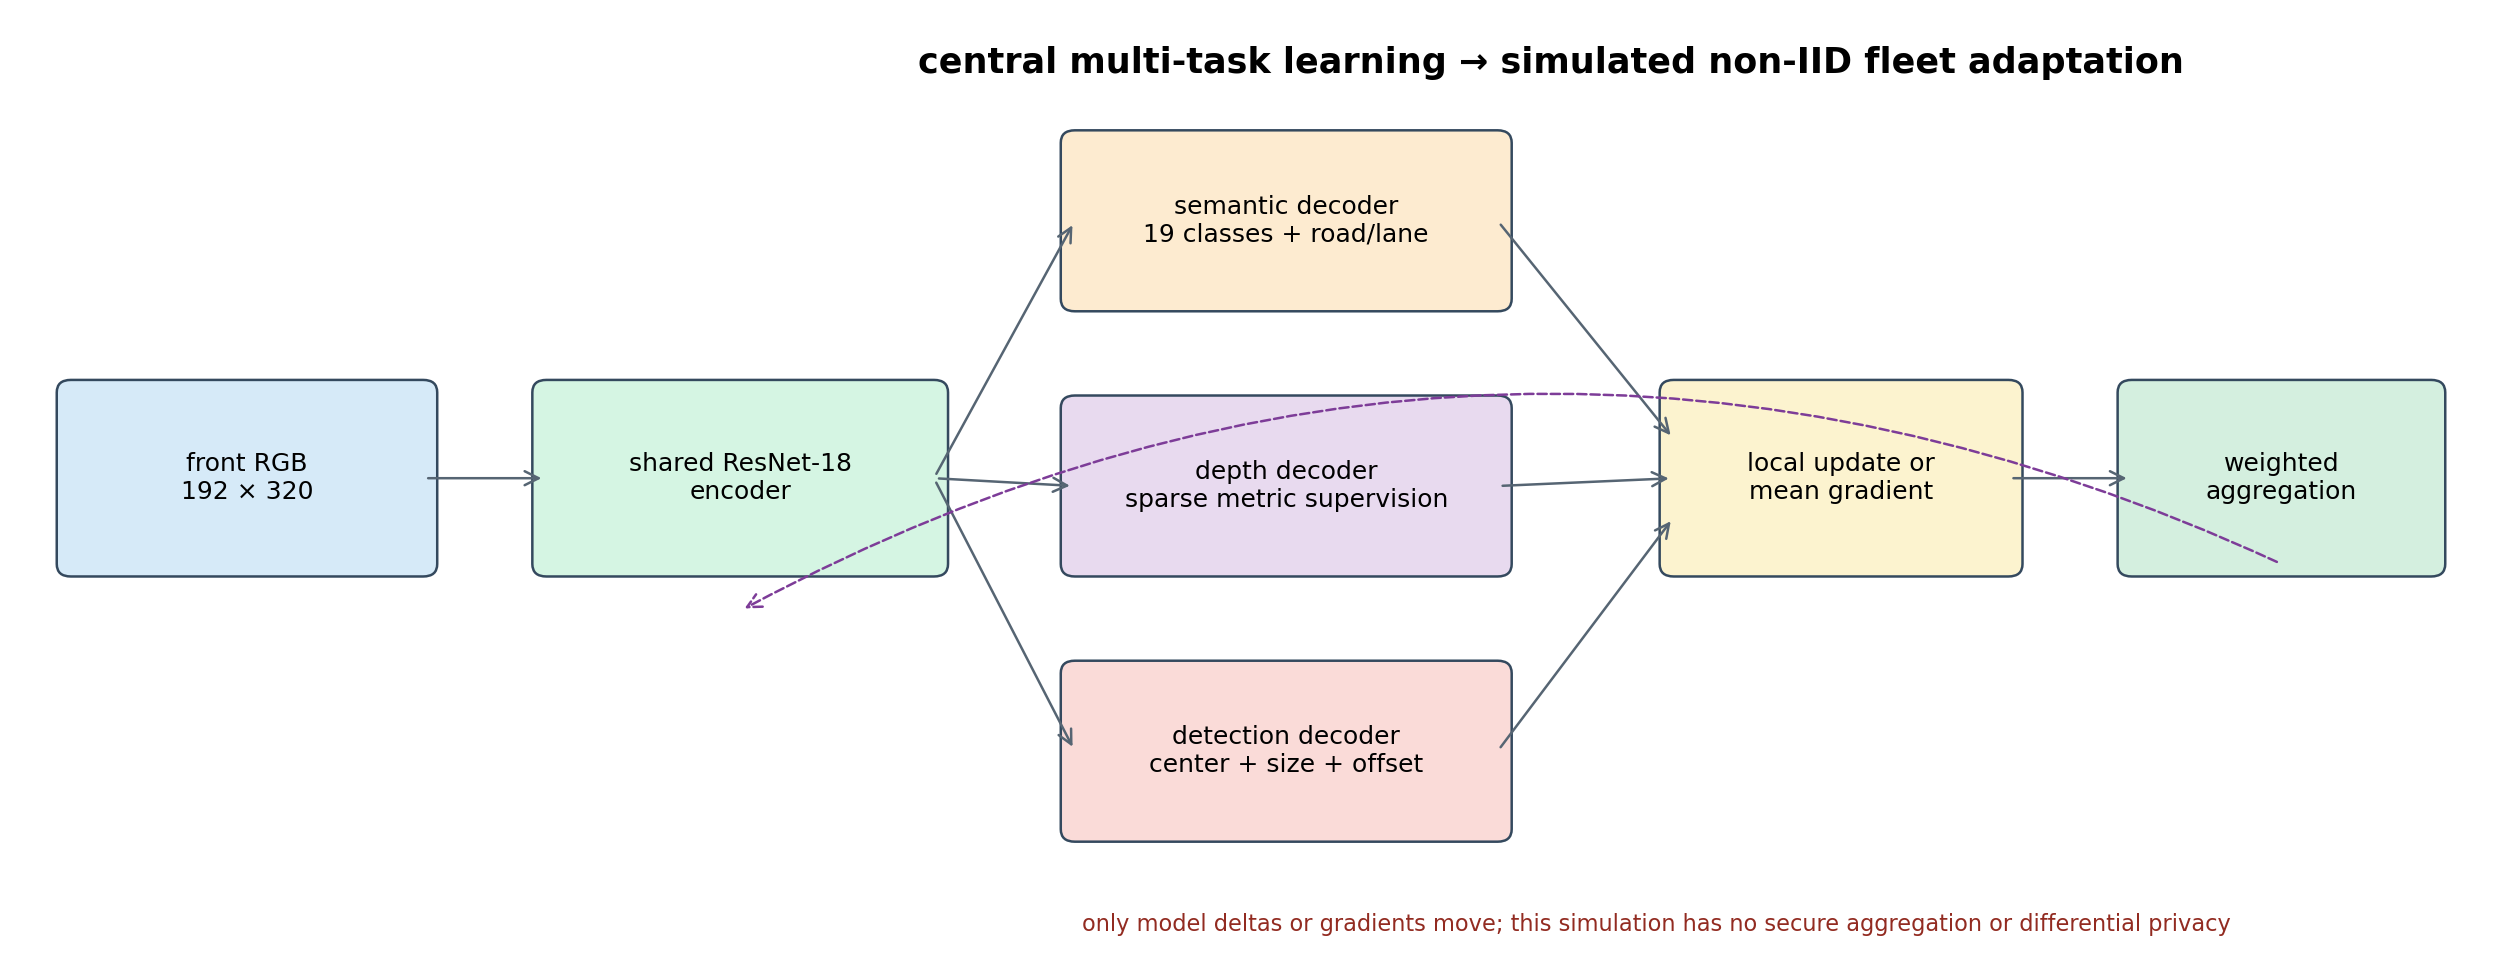

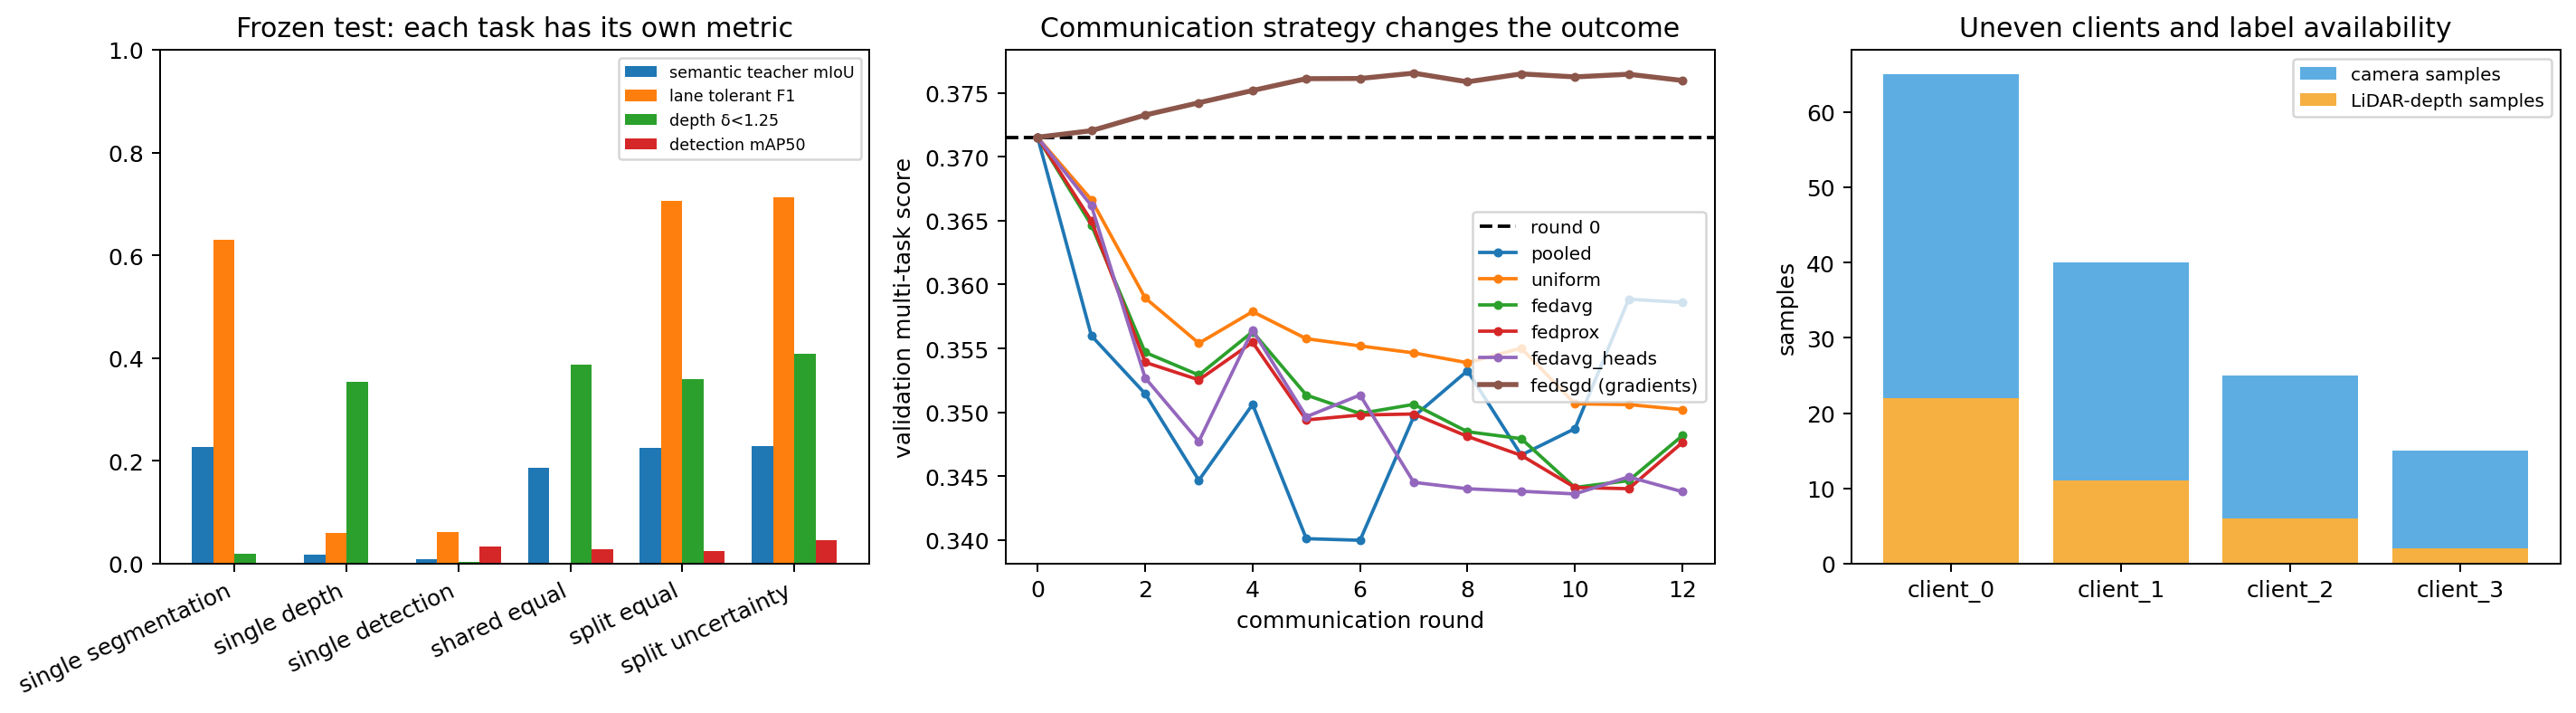

In [21]:
display(NotebookImage(filename=str(ROOT/'reports/figures/multitask_federated_pipeline.png')))
display(NotebookImage(filename=str(ROOT/'reports/figures/multitask_federated_benchmark.png')))

## What I keep from the experiment

The split decoder is the useful architectural result. It nearly matches the
single semantic model, improves native lane F1 and sparse depth over their
single-task controls, but trails detection-only AP. It uses one encoder pass
and less than half the parameters of three separate networks. Equal weighting
wins validation by a small margin over uncertainty weighting.

Local-optimizer FedAvg is a negative promotion result, but gradient-only FedSGD
is not. Its validation score rises from 0.3715 to 0.3765 and selects round 7.
On the once-read test role the composite score rises from 0.3392 to 0.3445,
mainly through sparse-depth $\delta_1$ (0.3586 to 0.3824), while detection mAP50
slips from 0.0252 to 0.0232. I therefore treat it as a useful multi-objective
trade rather than a universal per-task improvement.

## Implementation and reproduction map

| Stage | Implementation |
|---|---|
| private roles and client skew | `scripts/prepare_multitask_federated_roles.py` |
| teacher/depth/box cache | `scripts/build_multitask_federated_cache.py` |
| shared and split models | `src/zod_driveformer/multitask/models.py` |
| masked task losses and metrics | `src/zod_driveformer/multitask/losses.py`, `metrics.py` |
| model-delta FedAvg/FedProx and gradient-only FedSGD | `src/zod_driveformer/multitask/federated.py` |
| central and federated training | `scripts/train_multitask_central.py`, `run_multitask_federated.py` |

Private paths, identifiers, tensors, and weights remain outside Git. The
literature links and complete claim boundaries are in
`docs/multitask_federated_learning.md`.

In [22]:
required=['reports/multitask_federated_data.json','reports/multitask_central_test.json','reports/multitask_federated_test.json','reports/multitask_fedsgd_lr3e3_validation.json','reports/multitask_fedsgd_test.json','src/zod_driveformer/multitask/models.py','src/zod_driveformer/multitask/federated.py','docs/multitask_federated_learning.md']
checks=pd.DataFrame([(path,(ROOT/path).exists()) for path in required],columns=['artifact','present'])
assert checks.present.all(); checks

,artifact,present
0,reports/multitask_federated_data.json,True
1,reports/multitask_central_test.json,True
2,reports/multitask_federated_test.json,True
3,reports/multitask_fedsgd_lr3e3_validation.json,True
4,reports/multitask_fedsgd_test.json,True
5,src/zod_driveformer/multitask/models.py,True
6,src/zod_driveformer/multitask/federated.py,True
7,docs/multitask_federated_learning.md,True


## Questions I use to check my understanding

1. Why is uniform averaging not the pooled empirical objective?
2. Why is teacher mIoU useful without being ground-truth accuracy?
3. Where does the sparse depth mask enter the loss?
4. What does a negative task-gradient cosine mean locally?
5. Why can split decoders reduce interference without removing encoder conflict?
6. What failure does FedProx address?
7. Why must round zero be eligible for promotion?
8. What mechanisms are missing before I can make a privacy claim?
9. Why does sending a gradient avoid raw-data transfer without automatically
   reducing message size or guaranteeing privacy?
10. Why are full-weight and delta FedAvg equivalent from a shared checkpoint?

If I can derive the FedAvg weights, trace one box and one LiDAR point into their
targets, and explain why FedSGD earns an update while local FedAvg does not, I understand
the study rather than only remembering its plots.

## Primary references

Kendall et al. (CVPR 2018), PAD-Net (CVPR 2018), MTAN (CVPR 2019),
PCGrad (NeurIPS 2020), QuadroNet (WACV 2021), FedAvg (AISTATS 2017),
FedProx (MLSys 2020), SCAFFOLD (ICML 2020), and FedBN (ICLR 2021).
Direct links and notes on what I implemented versus only studied are in the
companion documentation.